###Análisis del notebook: https://www.kaggle.com/code/ajayganti/spotify-songs-genre-classification-e2e

El modelo tiene como objetivo predecir el género musical de una canción de Spotify con diferentes variables.

Primero se importa las librerias necesarias para el modelo.


*   Panda: Trabajar con datos
*   NumPy:
Hacer cálculos
*   Seaborn, matplotlib: Crear gráficos
*   Warning: Mostrar advertencias


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings

Esta celda permite ocultar advertencias, para que el notebook se vea más limpio

In [ ]:
warnings.filterwarnings('ignore')

Carga los datos del dataset que se va a utilizar para el modelo y los almacena en un DataFrame.

In [ ]:
df = pd.read_csv('../input/dataset-of-songs-in-spotify/genres_v2.csv')

Muestra las primeras cinco fila del DataFrame, lo cual nos permite identificar las variables y su estructura.

In [ ]:
df.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,id,uri,track_href,analysis_url,duration_ms,time_signature,genre,song_name,Unnamed: 0,title
0,0.831,0.814,2,-7.364,1,0.4200,0.0598,0.013400,0.0556,0.3890,...,2Vc6NJ9PW9gD9q343XFRKx,spotify:track:2Vc6NJ9PW9gD9q343XFRKx,https://api.spotify.com/v1/tracks/2Vc6NJ9PW9gD...,https://api.spotify.com/v1/audio-analysis/2Vc6...,124539,4,Dark Trap,Mercury: Retrograde,NaN,NaN
1,0.719,0.493,8,-7.230,1,0.0794,0.4010,0.000000,0.1180,0.1240,...,7pgJBLVz5VmnL7uGHmRj6p,spotify:track:7pgJBLVz5VmnL7uGHmRj6p,https://api.spotify.com/v1/tracks/7pgJBLVz5Vmn...,https://api.spotify.com/v1/audio-analysis/7pgJ...,224427,4,Dark Trap,Pathology,NaN,NaN
2,0.850,0.893,5,-4.783,1,0.0623,0.0138,0.000004,0.3720,0.0391,...,0vSWgAlfpye0WCGeNmuNhy,spotify:track:0vSWgAlfpye0WCGeNmuNhy,https://api.spotify.com/v1/tracks/0vSWgAlfpye0...,https://api.spotify.com/v1/audio-analysis/0vSW...,98821,4,Dark Trap,Symbiote,NaN,NaN
3,0.476,0.781,0,-4.710,1,0.1030,0.0237,0.000000,0.1140,0.1750,...,0VSXnJqQkwuH2ei1nOQ1nu,spotify:track:0VSXnJqQkwuH2ei1nOQ1nu,https://api.spotify.com/v1/tracks/0VSXnJqQkwuH...,https://api.spotify.com/v1/audio-analysis/0VSX...,123661,3,Dark Trap,ProductOfDrugs (Prod. The Virus and Antidote),NaN,NaN
4,0.798,0.624,2,-7.668,1,0.2930,0.2170,0.000000,0.1660,0.5910,...,4jCeguq9rMTlbMmPHuO7S3,spotify:track:4jCeguq9rMTlbMmPHuO7S3,https://api.spotify.com/v1/tracks/4jCeguq9rMTl...,https://api.spotify.com/v1/audio-analysis/4jCe...,123298,4,Dark Trap,Venom,NaN,NaN


Visualizar los nombres de todas las columnas del DataFrame, lo que nos permite identificar las variables que se pueden utilizar en el modelo y cuales no.

In [ ]:
df.columns

Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'type', 'id', 'uri', 'track_href', 'analysis_url', 'duration_ms',
       'time_signature', 'genre', 'song_name', 'Unnamed: 0', 'title'],
      dtype='object')

# Exploratory Data Analysis

Contar la cantidad de datos faltantes en cada columna.

In [ ]:
df.isna().sum()

danceability            0
energy                  0
key                     0
loudness                0
mode                    0
speechiness             0
acousticness            0
instrumentalness        0
liveness                0
valence                 0
tempo                   0
type                    0
id                      0
uri                     0
track_href              0
analysis_url            0
duration_ms             0
time_signature          0
genre                   0
song_name           20786
Unnamed: 0          21525
title               21525
dtype: int64

Only the columns song_name, unnamed: 0 and title are having missing values.

Se selecciona una cantidad de columnas y revisa las primeras diez filas, para revisar si son útil para el modelo.

In [ ]:
df[['type','id','uri','track_href','analysis_url','song_name','Unnamed: 0', 'title']].head(10)

,type,id,uri,track_href,analysis_url,song_name,Unnamed: 0,title
0,audio_features,2Vc6NJ9PW9gD9q343XFRKx,spotify:track:2Vc6NJ9PW9gD9q343XFRKx,https://api.spotify.com/v1/tracks/2Vc6NJ9PW9gD...,https://api.spotify.com/v1/audio-analysis/2Vc6...,Mercury: Retrograde,NaN,NaN
1,audio_features,7pgJBLVz5VmnL7uGHmRj6p,spotify:track:7pgJBLVz5VmnL7uGHmRj6p,https://api.spotify.com/v1/tracks/7pgJBLVz5Vmn...,https://api.spotify.com/v1/audio-analysis/7pgJ...,Pathology,NaN,NaN
2,audio_features,0vSWgAlfpye0WCGeNmuNhy,spotify:track:0vSWgAlfpye0WCGeNmuNhy,https://api.spotify.com/v1/tracks/0vSWgAlfpye0...,https://api.spotify.com/v1/audio-analysis/0vSW...,Symbiote,NaN,NaN
3,audio_features,0VSXnJqQkwuH2ei1nOQ1nu,spotify:track:0VSXnJqQkwuH2ei1nOQ1nu,https://api.spotify.com/v1/tracks/0VSXnJqQkwuH...,https://api.spotify.com/v1/audio-analysis/0VSX...,ProductOfDrugs (Prod. The Virus and Antidote),NaN,NaN
4,audio_features,4jCeguq9rMTlbMmPHuO7S3,spotify:track:4jCeguq9rMTlbMmPHuO7S3,https://api.spotify.com/v1/tracks/4jCeguq9rMTl...,https://api.spotify.com/v1/audio-analysis/4jCe...,Venom,NaN,NaN
5,audio_features,6fsypiJHyWmeINsOLC1cos,spotify:track:6fsypiJHyWmeINsOLC1cos,https://api.spotify.com/v1/tracks/6fsypiJHyWme...,https://api.spotify.com/v1/audio-analysis/6fsy...,Gatteka,NaN,NaN
6,audio_features,0XfQbq7DaMOmVXgQ71eA6E,spotify:track:0XfQbq7DaMOmVXgQ71eA6E,https://api.spotify.com/v1/tracks/0XfQbq7DaMOm...,https://api.spotify.com/v1/audio-analysis/0XfQ...,kamikaze (+ pulse),NaN,NaN
7,audio_features,0LLeuNBWPOg3XA73yab3PT,spotify:track:0LLeuNBWPOg3XA73yab3PT,https://api.spotify.com/v1/tracks/0LLeuNBWPOg3...,https://api.spotify.com/v1/audio-analysis/0LLe...,T.R.U. (Totally Rotten Underground),NaN,NaN
8,audio_features,37gqBnUAZe8BY8WR56kDNk,spotify:track:37gqBnUAZe8BY8WR56kDNk,https://api.spotify.com/v1/tracks/37gqBnUAZe8B...,https://api.spotify.com/v1/audio-analysis/37gq...,I Put My Dick in Your Mental,NaN,NaN
9,audio_features,2ggqfj97qyiORmXoVFzP5j,spotify:track:2ggqfj97qyiORmXoVFzP5j,https://api.spotify.com/v1/tracks/2ggqfj97qyiO...,https://api.spotify.com/v1/audio-analysis/2ggq...,Andromeda,NaN,NaN


The columns type,id,uri,track_href,analysis_url,song_name,Unnamed: 0,title has no significance. So dropping those columns

Después de revisar las columnas de la celda anterior, se concluye que no aporta información para predecir el género musical, con características musicales, por esto se decide eliminar.

In [ ]:
df.drop(['type','id','uri','track_href','analysis_url','song_name','Unnamed: 0', 'title'], axis = 1, inplace=True)

In [ ]:
df.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,genre
0,0.831,0.814,2,-7.364,1,0.4200,0.0598,0.013400,0.0556,0.3890,156.985,124539,4,Dark Trap
1,0.719,0.493,8,-7.230,1,0.0794,0.4010,0.000000,0.1180,0.1240,115.080,224427,4,Dark Trap
2,0.850,0.893,5,-4.783,1,0.0623,0.0138,0.000004,0.3720,0.0391,218.050,98821,4,Dark Trap
3,0.476,0.781,0,-4.710,1,0.1030,0.0237,0.000000,0.1140,0.1750,186.948,123661,3,Dark Trap
4,0.798,0.624,2,-7.668,1,0.2930,0.2170,0.000000,0.1660,0.5910,147.988,123298,4,Dark Trap


# Data Visualization

## Genre

Visualizar la cantidad de canciones que pertenencen a cada grupo de género musical.

In [ ]:
pd.DataFrame(df['genre'].value_counts())

,genre
Underground Rap,5875
Dark Trap,4578
Hiphop,3028
trance,2999
trap,2987
techhouse,2975
dnb,2966
psytrance,2961
techno,2956
hardstyle,2936


Text(0, 0.5, 'Count')

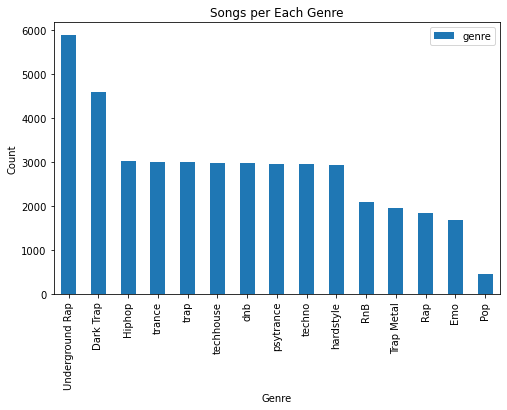

In [ ]:
ax = pd.DataFrame(df['genre'].value_counts()).plot(kind='bar',figsize=(8,5))
ax.set_title('Songs per Each Genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Count')

The Genre Pop has
very less number of songs while the Underground Rap has nearly 6K songs

## Danceability

Visualizar que tan bailables son las canciones.

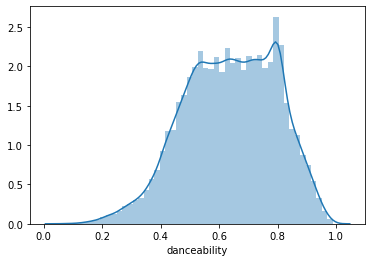

In [ ]:
sns.distplot(df['danceability'])

La mayor parte aparece ceca de 0.8, lo que significa que muchas canciones del dataset son altamente bailable.

## Energy

Visualizar la intensidad y actividad de la canción.

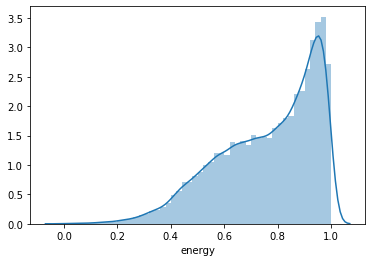

In [ ]:
sns.distplot(df['energy'])

La mayor cantidad de canciones tienen una energía alta.

## key

Visualizar cantidad de canciones que hay por tonalidad.

In [ ]:
df['key'].value_counts()

1     7537
7     4275
11    4150
6     3714
0     3470
8     3345
9     3254
10    3251
2     3047
5     2994
4     2368
3      900
Name: key, dtype: int64

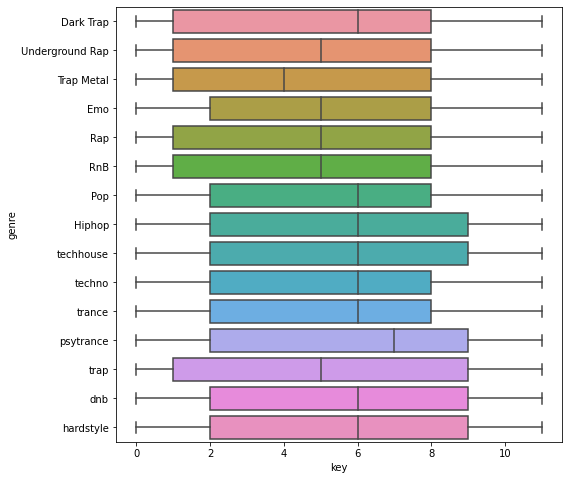

In [ ]:
fig_dims = (8, 8)
fig, ax = plt.subplots(figsize=fig_dims)
sns.boxplot(x='key',y='genre',data=df, ax=ax)

La mayoria de los generos tienen una mediana cercana a 5-6 y utilizan tonalidades entre 0 y 11.

## Loudness

Visualizar los niveles de volumen más comunes.

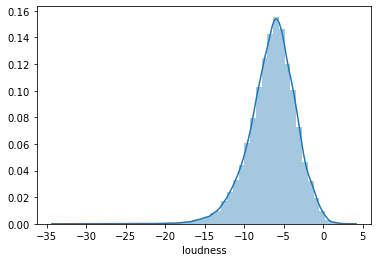

In [ ]:
sns.distplot(df['loudness'])

La mayor concentración de canciones tiene un columen promedio cercano a -5.

## Mode

Visualizar si las canciones estan compuestas en una escala mayor(1) o menor(0).

In [ ]:
df['mode'].value_counts()

1    23245
0    19060
Name: mode, dtype: int64

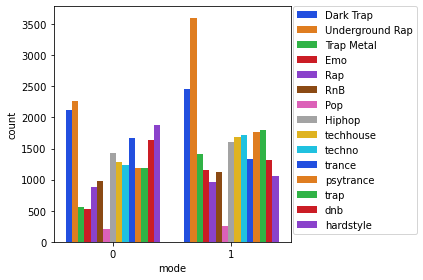

In [ ]:
sns.countplot(x='mode',data=df, hue='genre', palette='bright')
plt.legend(bbox_to_anchor=(1.01, 1),borderaxespad=0)
plt.tight_layout()

Los generos estan asociados a las dos escalas.

## Speechiness

Visualizar que tanta voz hablada contiene una canción.

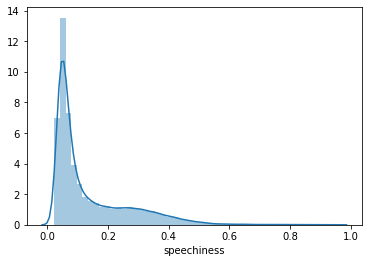

In [ ]:
sns.distplot(df['speechiness'])

La mayoría de canciones tienen más música o canto que voz hablada.

## Acousticness

Visualizar que tan acústicas son las canciones.

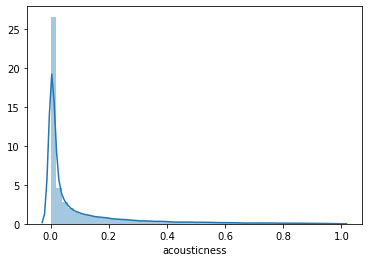

In [ ]:
sns.distplot(df['acousticness'])

La mayoria de las canciones son poco acústicas.

## Instrumentalness

Visualizar que tan instrumentales son las canciones.

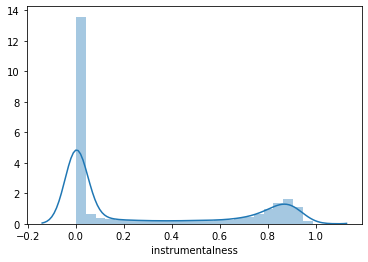

In [ ]:
sns.distplot(df['instrumentalness'])

La mayoría de las canciones tienen valores cercanos a 0, lo que indica que la mayoria contiene voz.

## Liveness

Viusalizar que tantas canciones fueron grabadas en vivo.

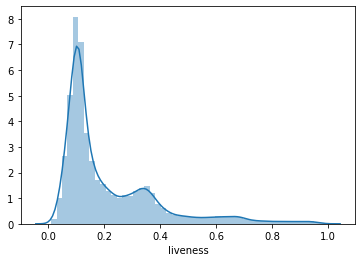

In [ ]:
sns.distplot(df['liveness'])

La mayoría de las canciones fueron grabadas en estudio y un pequeño procentaje son grabaciones en vivo.

## Valence

Visualizar los estados de anímo que trasmiten las canciones del dataset.

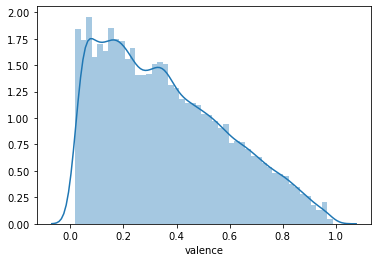

In [ ]:
sns.distplot(df['valence'])

Hay mayor distribución en valores bajos e intermedios, lo que quiere decir que hay pocas canciones alegres o positivas.

## Tempo

Visualizar la velocidad de las canciones.

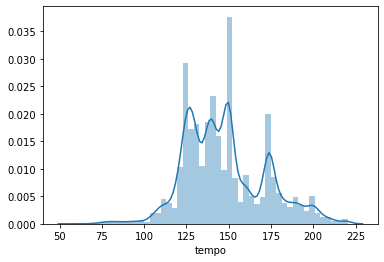

In [ ]:
sns.distplot(df['tempo'])

Hay un distribución multimodal, ya que hay varios picos, ya que hay diferentes géneros musicales que hacen que varíe el tiempo.

## duration_ms

Visualizar la duración de las canciones.

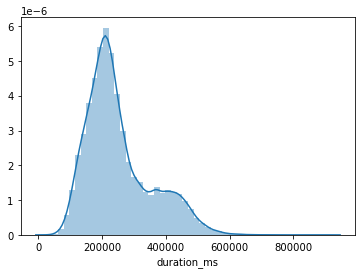

In [ ]:
sns.distplot(df['duration_ms'])

La mayoria de las canciones tienen una duración aproximada de 3 y 4 minutos.

## time signature

Visualizar que compás tienen las canciones.

In [ ]:
df['time_signature'].value_counts()

4    40427
3     1219
5      509
1      150
Name: time_signature, dtype: int64

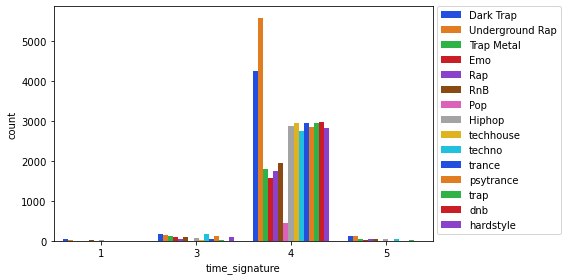

In [ ]:
fig_dims = (8, 4)
fig, ax = plt.subplots(figsize=fig_dims)
sns.countplot(x='time_signature',data=df, hue='genre', palette='bright', ax= ax)
plt.legend(bbox_to_anchor=(1.01, 1),borderaxespad=0)
plt.tight_layout()

La mayoria de las canciones esta en el compás 4.

1. There is no significance for the columns time_signature, mode and key since there is no proper insight from those data. So dropping those columns
2. Danceability distribution looks like gaussian but not exactly gaussian distribution
3. No conclusion can be drawn from the distribution of energy
4. The distribution of loudness looks like gaussian distribution
5. The distribution of speechiness and Acousticness resembles like chi-square-esque distribution
6. Instrumentalness has more zero values
7. valence - valence in music descibes the musical positiveness conveyed by the song. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry). (Source: https://towardsdatascience.com/what-makes-a-song-likeable-dbfdb7abe404#:~:text=Valence%3A%20Describes%20the%20musical%20positiveness,measure%20of%20intensity%20and%20activity)
8. Tempo follows a normal distribution (almost)

In [ ]:
df.drop(['time_signature','mode','key'], axis = 1, inplace=True)

## Label Encoding the Genre

Para poder utilizar la variable genre la cual contiene valores tipo texto hay que pasarla a un valor númerico.

In [ ]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
df['genre_encoded'] = LabelEncoder().fit_transform(df['genre'])

Se asigna un número único a cada género.

In [ ]:
#Label Encoder Mapping Reference
le = LabelEncoder()
le.fit(df['genre'])
le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(le_name_mapping)

{'Dark Trap': 0, 'Emo': 1, 'Hiphop': 2, 'Pop': 3, 'Rap': 4, 'RnB': 5, 'Trap Metal': 6, 'Underground Rap': 7, 'dnb': 8, 'hardstyle': 9, 'psytrance': 10, 'techhouse': 11, 'techno': 12, 'trance': 13, 'trap': 14}


In [ ]:
df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,genre,genre_encoded
0,0.831,0.814,-7.364,0.4200,0.0598,0.013400,0.0556,0.3890,156.985,124539,Dark Trap,0
1,0.719,0.493,-7.230,0.0794,0.4010,0.000000,0.1180,0.1240,115.080,224427,Dark Trap,0
2,0.850,0.893,-4.783,0.0623,0.0138,0.000004,0.3720,0.0391,218.050,98821,Dark Trap,0
3,0.476,0.781,-4.710,0.1030,0.0237,0.000000,0.1140,0.1750,186.948,123661,Dark Trap,0
4,0.798,0.624,-7.668,0.2930,0.2170,0.000000,0.1660,0.5910,147.988,123298,Dark Trap,0


Matriz de correlación, para observar cuales sob las relaciones fuertes entre las variables.

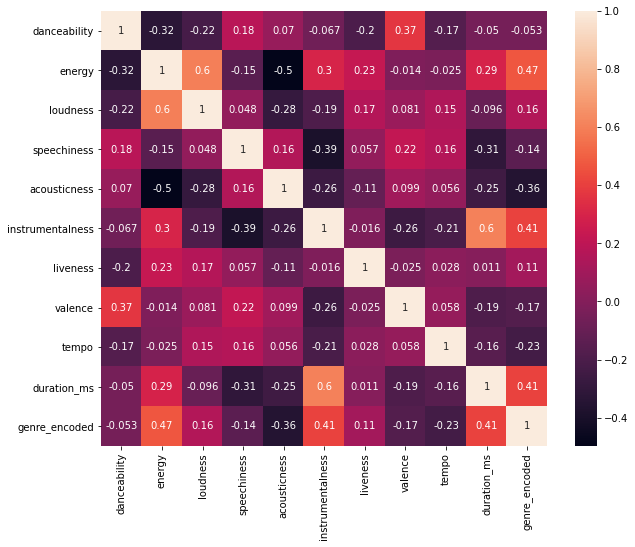

In [ ]:
fig_dims = (10, 8)
fig, ax = plt.subplots(figsize=fig_dims)
sns.heatmap(df.corr(), annot=True, ax=ax)

In [ ]:
df.corr()['genre_encoded']

danceability       -0.052687
energy              0.471327
loudness            0.160771
speechiness        -0.144596
acousticness       -0.356286
instrumentalness    0.414434
liveness            0.107690
valence            -0.170698
tempo              -0.231731
duration_ms         0.412508
genre_encoded       1.000000
Name: genre_encoded, dtype: float64

Instrumentalness, duration_ms, energy are positively correlated while acousticness and tempo are negatively correlated

Mediante el mapa de calor, identificamos la relación entre las variables y el género musical.

Las variables instrumentalness, duration_ms y energy tienen una tendencia positiva, al contrario de acousticness y tempo.

In [ ]:
df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,genre,genre_encoded
0,0.831,0.814,-7.364,0.4200,0.0598,0.013400,0.0556,0.3890,156.985,124539,Dark Trap,0
1,0.719,0.493,-7.230,0.0794,0.4010,0.000000,0.1180,0.1240,115.080,224427,Dark Trap,0
2,0.850,0.893,-4.783,0.0623,0.0138,0.000004,0.3720,0.0391,218.050,98821,Dark Trap,0
3,0.476,0.781,-4.710,0.1030,0.0237,0.000000,0.1140,0.1750,186.948,123661,Dark Trap,0
4,0.798,0.624,-7.668,0.2930,0.2170,0.000000,0.1660,0.5910,147.988,123298,Dark Trap,0


Separar la variable objetivo, con las variables de estudio.

In [ ]:
X = df.drop(['genre_encoded','genre'], axis = 1)
y = df['genre_encoded']

Dividir los datos de prueba 25% y de entrenamiento 75%.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [ ]:
X_train.describe() ## Before Standardization

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,31728.000000,31728.000000,31728.000000,31728.000000,31728.000000,31728.000000,31728.000000,31728.000000,31728.000000,31728.000000
mean,0.639068,0.763172,-6.462505,0.136987,0.095551,0.284028,0.214269,0.357036,147.531043,250888.068930
std,0.156571,0.183094,2.941284,0.126475,0.170023,0.371490,0.176197,0.232567,23.806356,103147.562784
min,0.065100,0.000243,-33.357000,0.022700,0.000001,0.000000,0.010700,0.018700,64.331000,25600.000000
25%,0.524000,0.633000,-8.163000,0.049300,0.001710,0.000000,0.099600,0.162000,129.941500,179905.250000
50%,0.645000,0.804000,-6.242000,0.075900,0.016100,0.005835,0.135000,0.322000,144.976000,224575.000000
75%,0.766000,0.922250,-4.508000,0.194000,0.106000,0.724000,0.294000,0.521000,161.900000,301587.000000
max,0.988000,1.000000,3.148000,0.946000,0.987000,0.989000,0.988000,0.988000,220.290000,913052.000000


Tempo and duration_ms should be standardized

Se aplica una estandarización a las variables tempo y duration_ms, ya que sus valores tienen escalas diferentes al resto.

In [ ]:
std = StandardScaler().fit(X_train[['tempo']])
X_train['tempo'] = std.transform(X_train[['tempo']])
X_test['tempo'] = std.transform(X_test[['tempo']])

std = StandardScaler().fit(X_train[['duration_ms']])
X_train['duration_ms'] = std.transform(X_train[['duration_ms']])
X_test['duration_ms'] = std.transform(X_test[['duration_ms']])

In [ ]:
X_train.describe() ## After Standardization

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,31728.000000,31728.000000,31728.000000,31728.000000,31728.000000,31728.000000,31728.000000,31728.000000,3.172800e+04,3.172800e+04
mean,0.639068,0.763172,-6.462505,0.136987,0.095551,0.284028,0.214269,0.357036,-5.451983e-16,-1.552241e-17
std,0.156571,0.183094,2.941284,0.126475,0.170023,0.371490,0.176197,0.232567,1.000016e+00,1.000016e+00
min,0.065100,0.000243,-33.357000,0.022700,0.000001,0.000000,0.010700,0.018700,-3.494922e+00,-2.184168e+00
25%,0.524000,0.633000,-8.163000,0.049300,0.001710,0.000000,0.099600,0.162000,-7.388708e-01,-6.881785e-01
50%,0.645000,0.804000,-6.242000,0.075900,0.016100,0.005835,0.135000,0.322000,-1.073278e-01,-2.551052e-01
75%,0.766000,0.922250,-4.508000,0.194000,0.106000,0.724000,0.294000,0.521000,6.035860e-01,4.915262e-01
max,0.988000,1.000000,3.148000,0.946000,0.987000,0.989000,0.988000,0.988000,3.056331e+00,6.419680e+00


# Model Building

### The metric should be Confusion Matrix and F1 score since it is a multi class classification. Accuracy can't be used for a multi class classification since interpretability is low

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,f1_score, accuracy_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [ ]:
def plot_confusion_matrix(test_y, predict_y, plot_title):
    C = confusion_matrix(test_y, predict_y)
    labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
    cmap=sns.light_palette("green")
    # representing A in heatmap format
    print("-"*50, "Confusion matrix", "-"*50)
    plt.figure(figsize=(15,12))
    sns.heatmap(C, annot=True, cmap=cmap, fmt=".3f", xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Class')
    plt.ylabel('Original Class')
    plt.title(plot_title)
    plt.show()

### The confusion matrix function plots the confusion matrix for the given inputs

## Decision Tree

In [ ]:
parameters = {"max_depth":np.array([1, 2, 5, 10, 50, 100]), "min_samples_split":np.array([1, 5, 10, 50, 100, 500])}
dt_clf = DecisionTreeClassifier(random_state=42)
clf = GridSearchCV(dt_clf, parameters, cv=5, scoring='f1_micro', n_jobs=-1, verbose=10)
clf.fit(X_train, y_train)
print(clf.best_estimator_)
print(clf.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.0189s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1495s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  92 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Batch computation too slow (2.0063s.) Setting batch_size=1.
[Parallel(n_jobs=-1)]: Done 128 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:    9.1s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 180 out of 180 | elapsed:   12.0s finished


DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42)
{'max_depth': 10, 'min_samples_split': 10}


-------------------------------------------------- Confusion matrix --------------------------------------------------


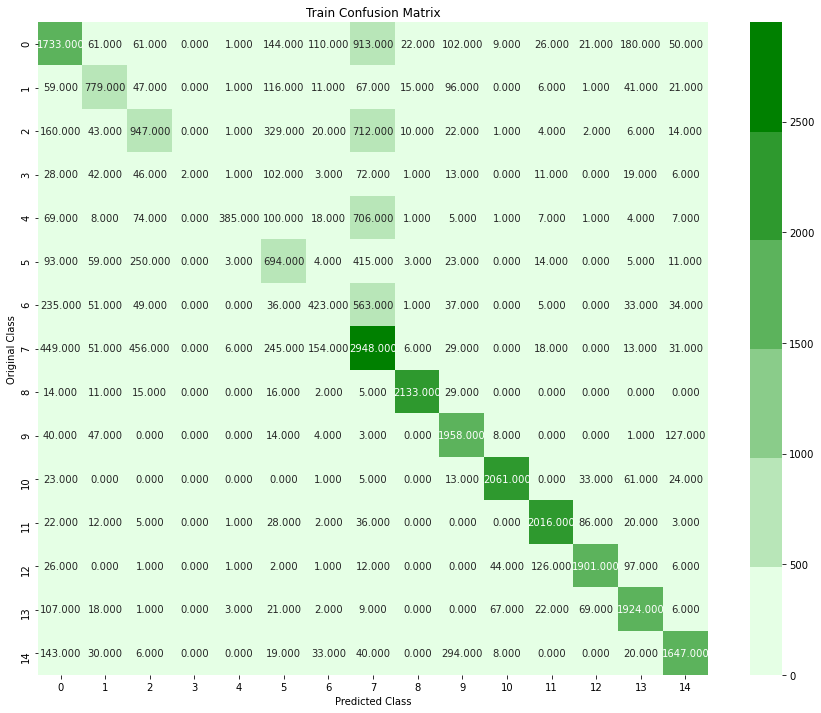

-------------------------------------------------- Confusion matrix --------------------------------------------------


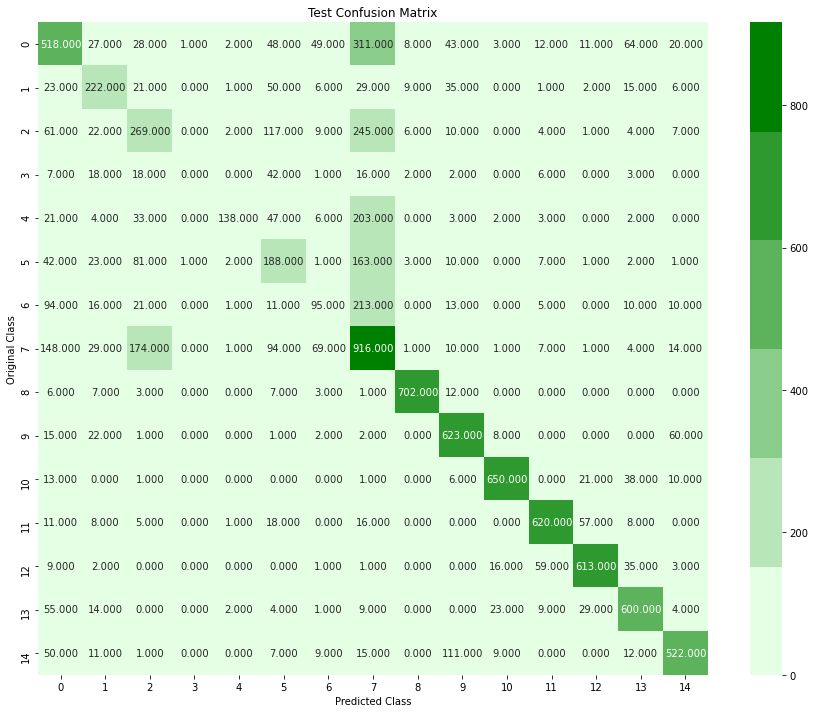

In [ ]:
clf = DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42)
clf.fit(X_train,y_train)
y_train_pred = clf.predict(X_train)
y_pred = clf.predict(X_test)
# Train Confusion Matrix
plot_confusion_matrix(y_train,y_train_pred, 'Train Confusion Matrix')
# Test Confusion Matrix
plot_confusion_matrix(y_test,y_pred, 'Test Confusion Matrix')

In [ ]:
print('Train F1 Score is {0}'.format(f1_score(y_train,y_train_pred,average='micro')))
print('Test F1 Score is {0}'.format(f1_score(y_test,y_pred,average='micro')))

Train F1 Score is 0.6792423096318709
Test F1 Score is 0.6311808641391699


## Random Forest

In [ ]:
parameters = {"n_estimators":np.array([10,50,100,250,350,500,750,1000,2000,3000]) ,"max_depth":np.array([1,5,8,10,50,70,100]),
              "min_samples_split":np.array([2,5,10,100,500])}
rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
clf = RandomizedSearchCV(rf_clf, parameters, cv=5, scoring='f1_micro', n_jobs=-1, verbose=10)
clf.fit(X_train, y_train)
print(clf.best_estimator_)
print(clf.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  3.9min
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:  6.9min
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  7.7min
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  8.0min finished


RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=750,
                       n_jobs=-1, random_state=42)
{'n_estimators': 750, 'min_samples_split': 10, 'max_depth': 10}


-------------------------------------------------- Confusion matrix --------------------------------------------------


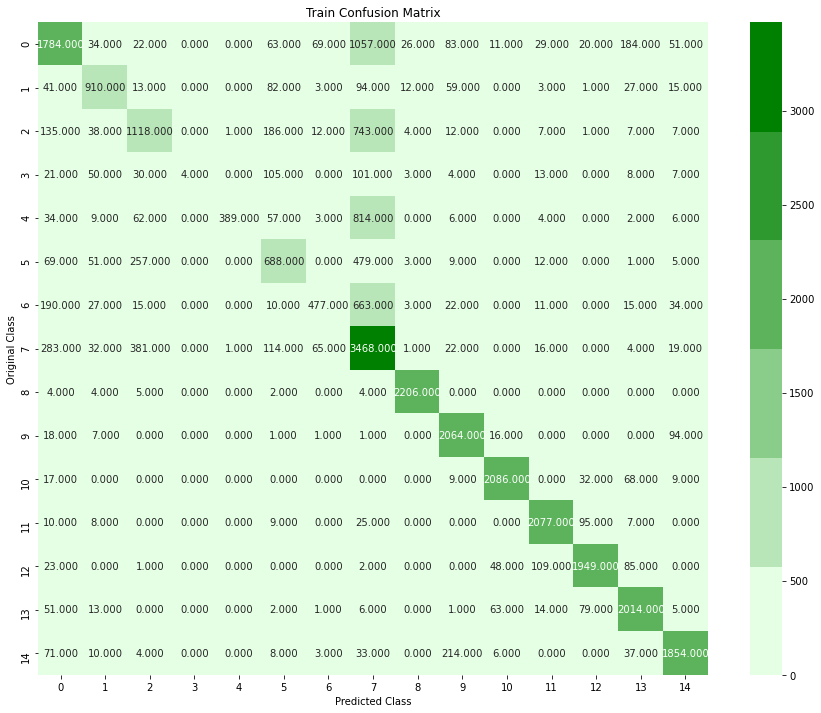

-------------------------------------------------- Confusion matrix --------------------------------------------------


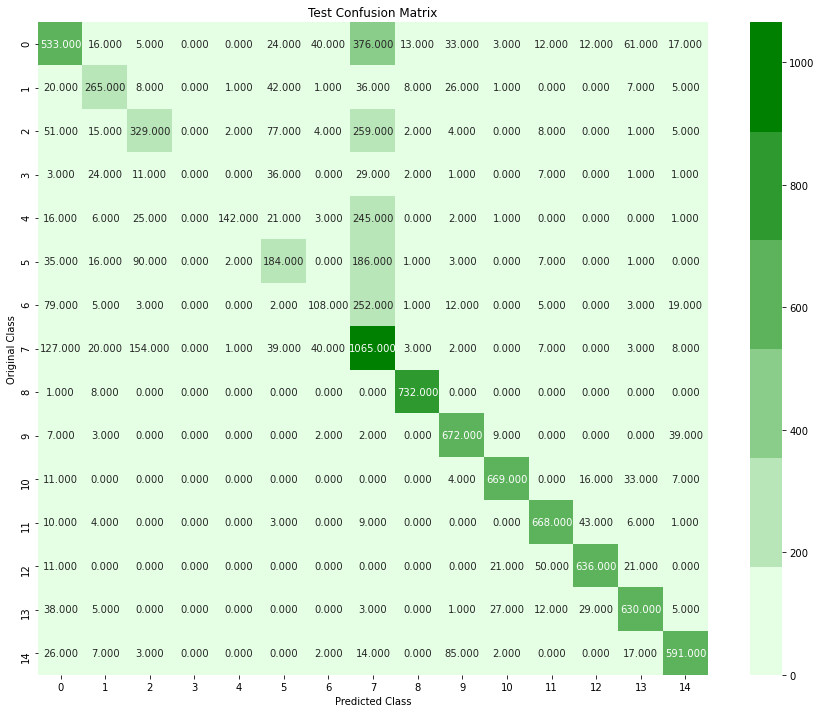

Train F1 Score is 0.7276853252647505
Test F1 Score is 0.6829913964262078


In [ ]:
clf = RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=750, n_jobs=-1, random_state=42)
clf.fit(X_train,y_train)
y_train_pred = clf.predict(X_train)
y_pred = clf.predict(X_test)
# Train Confusion Matrix
plot_confusion_matrix(y_train,y_train_pred, 'Train Confusion Matrix')
# Test Confusion Matrix
plot_confusion_matrix(y_test,y_pred, 'Test Confusion Matrix')
print('Train F1 Score is {0}'.format(f1_score(y_train,y_train_pred,average='micro')))
print('Test F1 Score is {0}'.format(f1_score(y_test,y_pred,average='micro')))

## XGBoost

In [ ]:
params = {
    'learning_rate':[0.01,0.03,0.05,0.1,0.15,0.2],
     'n_estimators':[100,200,350,500,1000,2000],
     'max_depth':[2,3,5,8,10],
    'colsample_bytree':[0.1,0.3,0.5,1],
    'colsample_bylevel':[0.1,0.3,0.5,1],
    'reg_alpha' : [0.001,0.01,0.1,1,10],
    'reg_lambda' : [0.001,0.01,0.1,1,10],
    'subsample':[0.1,0.3,0.5,1]
    }
xgb = XGBClassifier(n_jobs = -1)
clf = RandomizedSearchCV(xgb, params, cv=5, scoring='f1_micro', n_jobs=-1, verbose=10)
clf.fit(X_train, y_train)
print(clf.best_estimator_)
print(clf.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  8.5min
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed: 14.8min
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed: 22.2min
[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed: 28.6min
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed: 31.1min
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed: 33.1min finished


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.5, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.15, max_delta_step=0, max_depth=2,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=500, n_jobs=-1, num_parallel_tree=1,
              objective='multi:softprob', random_state=0, reg_alpha=1,
              reg_lambda=0.001, scale_pos_weight=None, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)
{'subsample': 1, 'reg_lambda': 0.001, 'reg_alpha': 1, 'n_estimators': 500, 'max_depth': 2, 'learning_rate': 0.15, 'colsample_bytree': 0.5, 'colsample_bylevel': 1}


-------------------------------------------------- Confusion matrix --------------------------------------------------


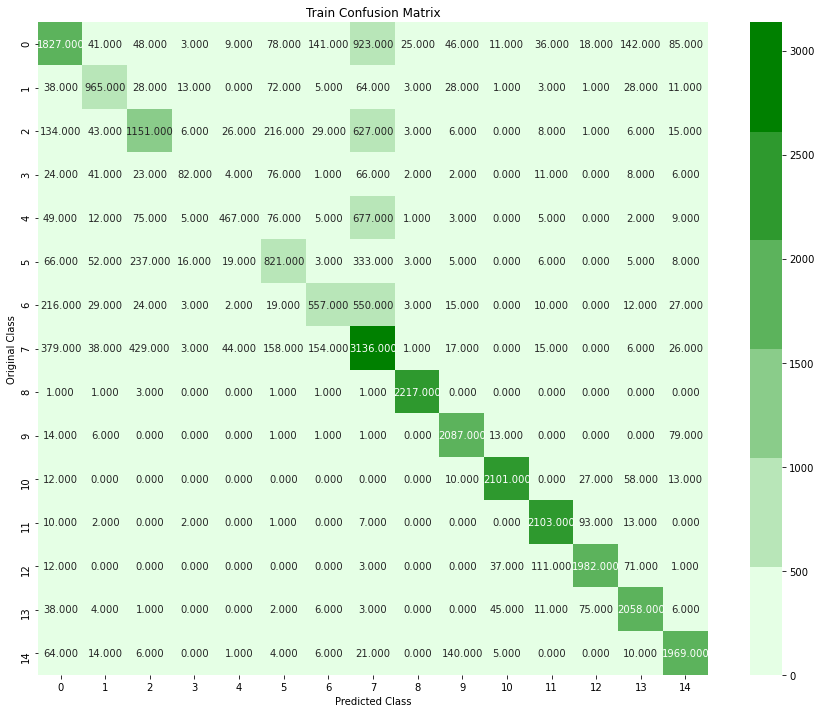

-------------------------------------------------- Confusion matrix --------------------------------------------------


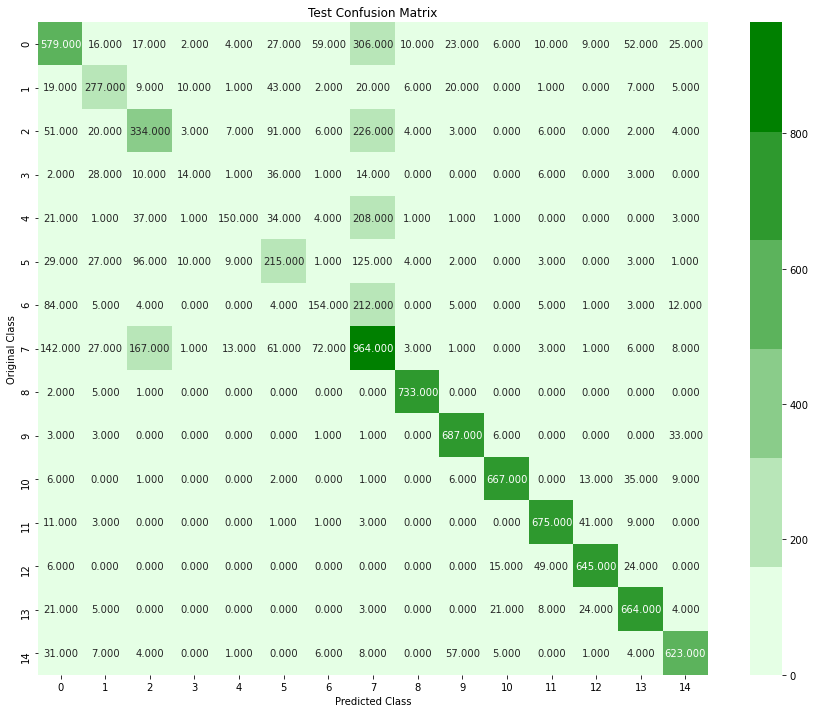

Train F1 Score is 0.7413956127080181
Test F1 Score is 0.6978349248369102


In [ ]:
clf = XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.5, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.15, max_delta_step=0, max_depth=2,
              min_child_weight=1, monotone_constraints='()',
              n_estimators=500, n_jobs=-1, num_parallel_tree=1,
              objective='multi:softprob', random_state=0, reg_alpha=1,
              reg_lambda=0.001, scale_pos_weight=None, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)
clf.fit(X_train,y_train)
y_train_pred = clf.predict(X_train)
y_pred = clf.predict(X_test)
# Train Confusion Matrix
plot_confusion_matrix(y_train,y_train_pred, 'Train Confusion Matrix')
# Test Confusion Matrix
plot_confusion_matrix(y_test,y_pred, 'Test Confusion Matrix')
print('Train F1 Score is {0}'.format(f1_score(y_train,y_train_pred,average='micro')))
print('Test F1 Score is {0}'.format(f1_score(y_test,y_pred,average='micro')))

### The model is getting confused in classifying certain data points belonging to some genre's like Dark Trap, Hiphop and RnB

# Results

In [ ]:
from prettytable import PrettyTable
results = []

# add the results in a list
results.append(['Model','Train F1','Test F1'])
results.append(['Decision Tree',0.679,0.631])
results.append(['Random Forest',0.727,0.683])
results.append(['XGBoost',0.741,0.697])

In [ ]:
table = PrettyTable()
table.field_names = results[0]
for i in range(len(results)):
    if i!=0:
        table.add_row(results[i])
print(table)

+---------------+----------+---------+
|     Model     | Train F1 | Test F1 |
+---------------+----------+---------+
| Decision Tree |  0.679   |  0.631  |
| Random Forest |  0.727   |  0.683  |
|    XGBoost    |  0.741   |  0.697  |
+---------------+----------+---------+


#### Despues de utilizar cada modelo se obtiene que el mejor desempeño fue de XGBoost con 0.679 en prueba, seguido de Random Forest con 0.683, y el Árbol de Decisión con 0.631. La diferencia se debe a cómo cada algoritmo hace sus predicciones. El Árbol de Decisión utiliza un solo árbol, lo que lo hace muy sensible a los datos de entrenamiento y propenso a errores. Random Forest mejora al combinar las votaciones de cientos de árboles, reduciendo el impacto de errores individuales. XGBoost construye árboles de forma secuencial, corrigiendo los errores de los árboles anteriores, lo que le permite aprender de manera más precisa.

- Es importante tratar el desbalance de clases en los datos, ya que hay muy pocas canciones de Pop en comparación con Underground Rap.

- Es importante identificar y eliminar datos duplicados para asegurar la calidad y precisión del análisis.